In [1]:
import pandas as pd
import itertools
from google.colab import files

# 色データ
colors = [
    {'name': '赤', 'hex': '#E60012'}, {'name': '赤橙', 'hex': '#EB6100'},
    {'name': '橙', 'hex': '#F39800'}, {'name': '黄橙', 'hex': '#FCC800'},
    {'name': '黄', 'hex': '#FFF100'}, {'name': '黄緑', 'hex': '#8FC31F'},
    {'name': '緑', 'hex': '#009944'}, {'name': '青緑', 'hex': '#009E96'},
    {'name': '青', 'hex': '#0068B7'}, {'name': '青紫', 'hex': '#1D2088'},
    {'name': '紫', 'hex': '#920783'}, {'name': '赤紫', 'hex': '#E5007F'}
]
color_names = [c['name'] for c in colors]
color_hexes = {c['name']: c['hex'] for c in colors}

# 音データ (12音階で１オクターブ)
sounds = ['C(ド)', 'C#(ド#)', 'D(レ)', 'D#(レ#)', 'E(ミ)', 'F(ファ)',
          'F#(ファ#)', 'G(ソ)', 'G#(ソ#)', 'A(ラ)', 'A#(ラ#)', 'B(シ)']


def create_pairs_csv(items, filename, hex_dict=None):
    pairs = list(itertools.combinations(items, 2))
    df = pd.DataFrame(pairs, columns=['Element_A', 'Element_B'])


    if hex_dict:
        df['Hex_A'] = df['Element_A'].map(hex_dict)
        df['Hex_B'] = df['Element_B'].map(hex_dict)
        df = df[['Element_A', 'Element_B', 'Hex_A', 'Hex_B']]


    df['Value_0_to_100'] = ""


    df.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"ファイルを作成しました: {filename}")
    try:
        files.download(filename)
    except:
        pass

create_pairs_csv(color_names, 'color_pairs.csv', color_hexes)
create_pairs_csv(sounds, 'sound_pairs.csv')


ファイルを作成しました: color_pairs.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ファイルを作成しました: sound_pairs.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
#csvファイルの読み取り
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
except:
    IN_COLAB = False

if IN_COLAB:
    path = '/content/drive/My Drive/'

filename = 'color_pairs.csv'

df_color = pd.read_csv(path+filename,header=0)

df_color

Mounted at /content/drive


,Element_A,Element_B,Hex_A,Hex_B,Value_0_to_100
0,赤,赤橙,#E60012,#EB6100,10
1,赤,橙,#E60012,#F39800,20
2,赤,黄橙,#E60012,#FCC800,25
3,赤,黄,#E60012,#FFF100,30
4,赤,黄緑,#E60012,#8FC31F,40
...,...,...,...,...,...
61,青,紫,#0068B7,#920783,40
62,青,赤紫,#0068B7,#E5007F,60
63,青紫,紫,#1D2088,#920783,40
64,青紫,赤紫,#1D2088,#E5007F,70


In [3]:
#csvファイルの読み取り
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
except:
    IN_COLAB = False

if IN_COLAB:
    path = '/content/drive/My Drive/'

filename = 'sound_pairs.csv'

df_sound = pd.read_csv(path+filename,header=0)

df_sound

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Element_A,Element_B,Value_0_to_100
0,C(ド),C#(ド#),90
1,C(ド),D(レ),60
2,C(ド),D#(レ#),30
3,C(ド),E(ミ),20
4,C(ド),F(ファ),30
...,...,...,...
61,G#(ソ#),A#(ラ#),65
62,G#(ソ#),B(シ),50
63,A(ラ),A#(ラ#),95
64,A(ラ),B(シ),75


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 33.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=6db954269fcf3cc2fe97f15a58989306f61963de91d3d212e7f1529954d4be64
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|1.575347e-01|0.000000e+00|0.000000e+00
    1|1.273867e-01|2.366650e-01|3.014797e-02
    2|8.953745e-02|4.227198e-01|3.784925e-02
    3|8.340892e-02|7.347580e-02|6.128537e-03
    4|8.340892e-02|0.000000e+00|0.000000e+00

【GW最適化による対応結果】
赤 <--> F#(ファ#) (確度: 0.08)
赤橙 <--> G(ソ) (確度: 0.08)
橙 <--> D(レ) 

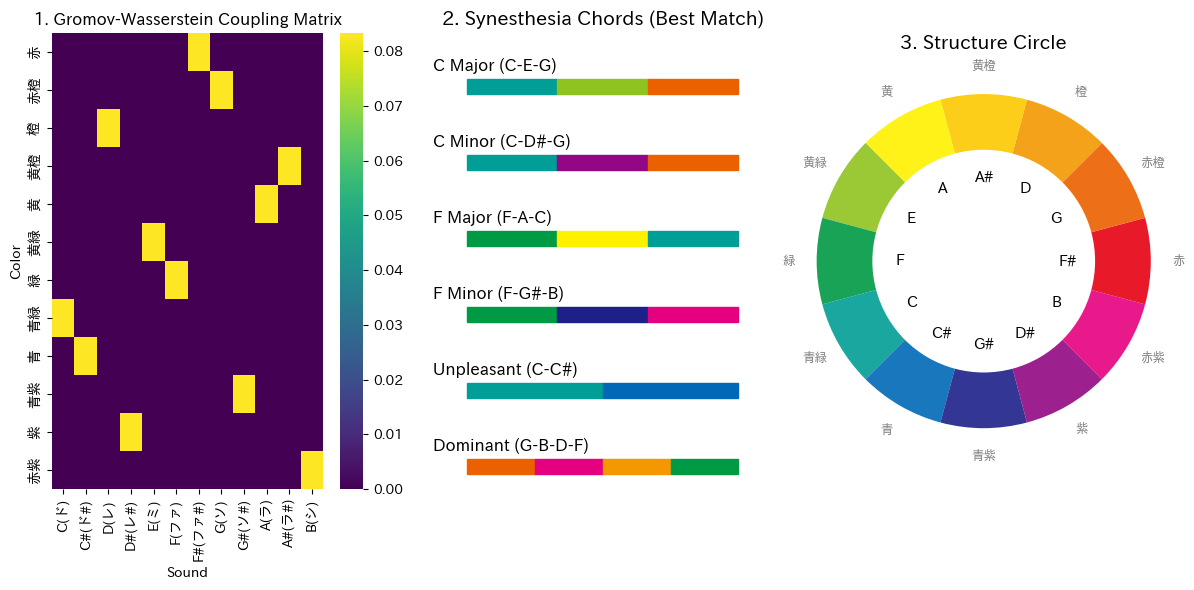

In [4]:
!pip install POT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ot
import matplotlib.patches as patches

!pip install japanize-matplotlib
import japanize_matplotlib


color_labels = ['赤', '赤橙', '橙', '黄橙', '黄', '黄緑', '緑', '青緑', '青', '青紫', '紫', '赤紫']
sound_labels = ['C(ド)', 'C#(ド#)', 'D(レ)', 'D#(レ#)', 'E(ミ)', 'F(ファ)', 'F#(ファ#)', 'G(ソ)', 'G#(ソ#)', 'A(ラ)', 'A#(ラ#)', 'B(シ)']

#大泉先生の講義にあったGW距離に基づくアラインメント

#色と音の行列を作り正規化する
color_hex_map = color_hexes if 'color_hexes' in globals() else {}
def create_distance_matrix(df, labels, value_col):
    n = len(labels)
    mat = np.zeros((n, n))
    label_to_idx = {l: i for i, l in enumerate(labels)}
    for _, row in df.iterrows():
        try:
            name_a, name_b = row['Element_A'].strip(), row['Element_B'].strip()
            if name_a in label_to_idx and name_b in label_to_idx:
                val = float(row[value_col])
                if np.isnan(val): val = 50.0
                i, j = label_to_idx[name_a], label_to_idx[name_b]
                mat[i, j] = mat[j, i] = val
        except: pass
    return mat / np.max(mat) if np.max(mat) > 0 else mat


col_c = 'Value_0_to_100'
col_s = 'Value_0_to_100'

C1 = create_distance_matrix(df_color, color_labels, col_c)
C2 = create_distance_matrix(df_sound, sound_labels, col_s)

#GW最適輸送を計算
p = ot.unif(len(color_labels))
q = ot.unif(len(sound_labels))
gw_map = ot.gromov.gromov_wasserstein(
    C1, C2, p, q, 'square_loss', verbose=True, log=False
)

# 以下結果を出力
plt.figure(figsize=(12, 6))

# ヒートマップ（色と音との関係の表で確率的に表されている）
plt.subplot(1, 3, 1)
sns.heatmap(gw_map, cmap='viridis', xticklabels=sound_labels, yticklabels=color_labels)
plt.title('1. Gromov-Wasserstein Coupling Matrix')
plt.xlabel('Sound')
plt.ylabel('Color')


print("\n【GW最適化による対応結果】")
mapping = {}
perm_sound_indices = np.argmax(gw_map, axis=1)
for i, color in enumerate(color_labels):
    best_match_idx = perm_sound_indices[i]
    sound = sound_labels[best_match_idx]
    prob = gw_map[i, best_match_idx]
    print(f"{color} <--> {sound} (確度: {prob:.2f})")

#色と音の変換を記録
sound_to_color_map = {}

perm_sound_indices = np.argmax(gw_map, axis=1)

for i, color in enumerate(color_labels):
    best_match_idx = perm_sound_indices[i]
    sound = sound_labels[best_match_idx]
    prob = gw_map[i, best_match_idx]

    hex_code = color_hex_map.get(color, '#CCCCCC')

    sound_to_color_map[sound] = {'color': color, 'hex': hex_code}

    print(f"{color} <--> {sound} (確度: {prob:.2f})")
# 和音と色の組との対応
chords_to_show = {
        'C Major (C-E-G)': ['C(ド)', 'E(ミ)', 'G(ソ)'],
        'C Minor (C-D#-G)': ['C(ド)', 'D#(レ#)', 'G(ソ)'],
        'F Major (F-A-C)': ['F(ファ)', 'A(ラ)', 'C(ド)'],
        'F Minor (F-G#-B)': ['F(ファ)', 'G#(ソ#)', 'B(シ)'],
        'Unpleasant (C-C#)': ['C(ド)', 'C#(ド#)'],
        'Dominant (G-B-D-F)':['G(ソ)', 'B(シ)','D(レ)','F(ファ)']
    }
ax2 = plt.subplot(1, 3, 2)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, len(chords_to_show))
ax2.axis('off')
plt.title('2. Synesthesia Chords (Best Match)', fontsize=14)
y_pos = len(chords_to_show) - 0.8
for name, notes in chords_to_show.items():
    ax2.text(0.0, y_pos + 0.3, name, fontsize=12, fontweight='bold')
    colors = []
    for note in notes:
        if note in sound_to_color_map:
            colors.append(sound_to_color_map[note]['hex'])
        else:
            colors.append('#CCCCCC')
    bar_width = 0.8 / len(colors)
    for k, col in enumerate(colors):
        rect = patches.Rectangle((0.1 + k*bar_width, y_pos), bar_width, 0.2, color=col)
        ax2.add_patch(rect)
    y_pos -= 1.0

# 色相環と対応している音を、色相環に沿うように表示する
ax3 = plt.subplot(1, 3, 3, polar=True)
theta = np.linspace(0, 2*np.pi, len(color_labels), endpoint=False)
width = 2*np.pi / len(color_labels)
bars = ax3.bar(theta, [1]*len(color_labels), width=width, bottom=2)
for i, bar in enumerate(bars):
    col_name = color_labels[i]
    bar.set_facecolor(color_hex_map.get(col_name, 'gray'))
    bar.set_alpha(0.9)
for i, color_label in enumerate(color_labels):
    sound_idx = perm_sound_indices[i]
    sound_label = sound_labels[sound_idx]
    angle = theta[i]
    ax3.text(angle, 1.5, sound_label.split('(')[0], ha='center', va='center', fontsize=11, fontweight='bold')
    ax3.text(angle, 3.5, color_label, ha='center', va='center', fontsize=9, color='gray')
plt.title('3. Structure Circle', fontsize=14, y=1.1)
plt.axis('off')
plt.tight_layout()
plt.show()


In [5]:
from scipy.optimize import quadratic_assignment
from scipy.stats import pearsonr
from sklearn.manifold import MDS
from scipy.spatial import procrustes


results = []
n = 12
upper_tri_indices = np.triu_indices(n, k=1)
vec_c = C1[upper_tri_indices]

#C（ド）が何色かを固定して、音階順に並んでいるとした時、構造の誤差を計算する
for shift in range(n):
    sound_indices = [(i - shift) % 12 for i in range(n)]
    D_s_rotated = C2[np.ix_(sound_indices, sound_indices)]

    error = np.sum((C1 - D_s_rotated)**2)

    vec_s = D_s_rotated[upper_tri_indices]
    if np.std(vec_c) == 0 or np.std(vec_s) == 0:
        corr = 0
    else:
        corr, _ = pearsonr(vec_c, vec_s)

    results.append({
        'C_mapped_to': color_labels[shift],
        'GW_Error': error,
        'Correlation': corr
    })

df_results = pd.DataFrame(results).sort_values('GW_Error')
print("\n【構造整合性ランキング 】")
print(df_results[['C_mapped_to', 'GW_Error', 'Correlation']].head(12))





【構造整合性ランキング 】
   C_mapped_to   GW_Error  Correlation
2            橙  25.382495    -0.463805
3           黄橙  25.561123    -0.474114
1           赤橙  25.812054    -0.488596
0            赤  25.937519    -0.495837
10           紫  26.220347    -0.512160
9           青紫  26.464898    -0.526274
4            黄  26.528694    -0.529956
11          赤紫  26.798763    -0.545542
8            青  26.907216    -0.551801
7           青緑  26.928481    -0.553029
5           黄緑  27.213436    -0.569474
6            緑  27.453734    -0.583343


【最適解】
赤 <--> A#(ラ#)
赤橙 <--> B(シ)
橙 <--> C(ド)
黄橙 <--> C#(ド#)
黄 <--> D(レ)
黄緑 <--> D#(レ#)
緑 <--> E(ミ)
青緑 <--> F(ファ)
青 <--> F#(ファ#)
青紫 <--> G(ソ)
紫 <--> G#(ソ#)
赤紫 <--> A(ラ)


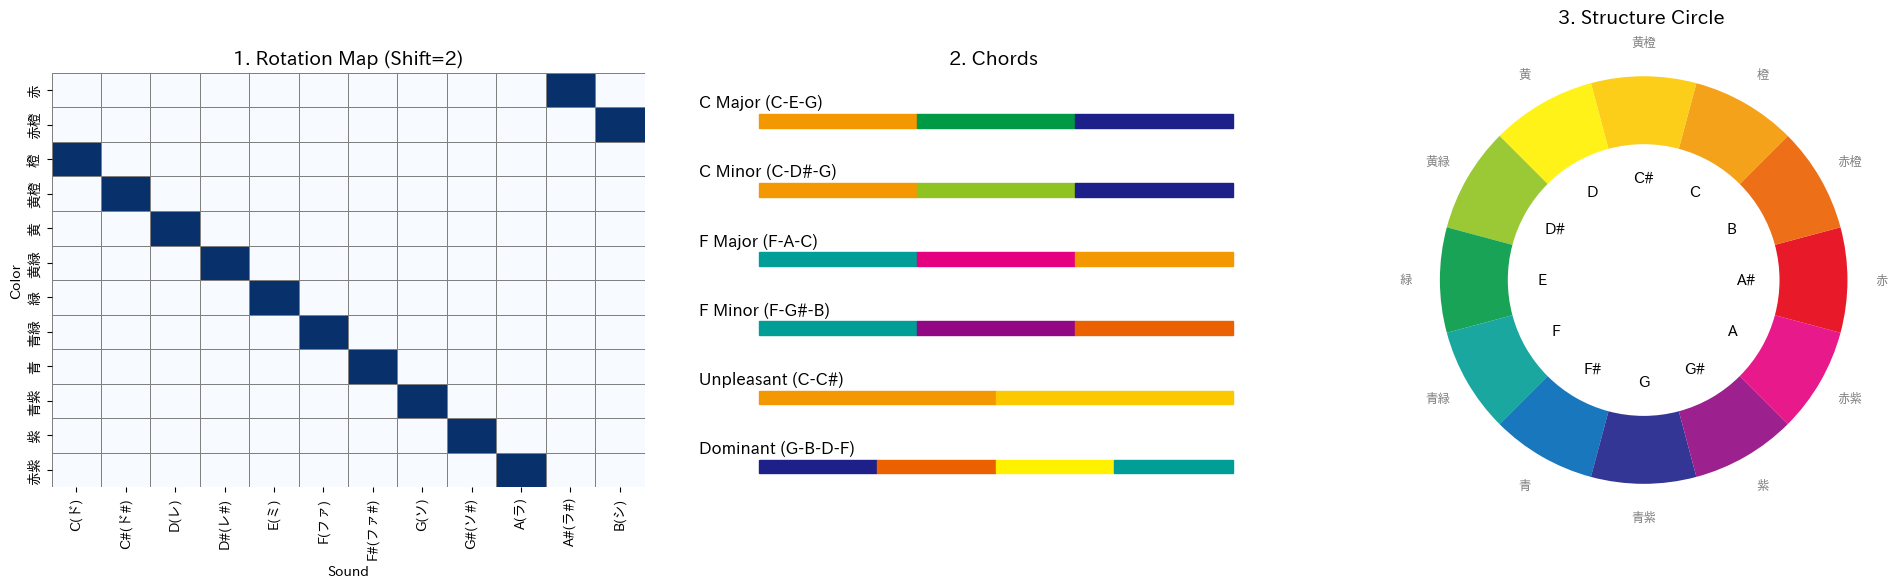

In [6]:
#回転させていくことでで最適解を見つける（色と音が同様に連続的に変化していると仮定）
best_error = float('inf')
best_shift = 0
best_perm_indices = []

n = 12
for shift in range(n):
    current_indices = [(i - shift) % 12 for i in range(n)]

    C_sound_rot = C2[np.ix_(current_indices, current_indices)]
    error = np.sum((C1 - C_sound_rot)**2)

    if error < best_error:
        best_error = error
        best_shift = shift
        best_perm_indices = current_indices

print(f"【最適解】")


mapping_result = {}
for i, color in enumerate(color_labels):
    sound_idx = best_perm_indices[i]
    sound_name = sound_labels[sound_idx]
    hex_code = color_hex_map.get(color, '#333333')
    mapping_result[sound_name] = {'color': color, 'hex': hex_code}
    print(f"{color} <--> {sound_name}")

sound_to_color_map = {s: mapping_result[s] for s in mapping_result}

#GWの時と同じような図表を作成する（この方法で最適になった時の）
plt.figure(figsize=(20, 6))



plt.subplot(1, 3, 1)
P_matrix = np.zeros((12, 12))
for i, j in enumerate(best_perm_indices):
    P_matrix[i, j] = 1.0
sns.heatmap(P_matrix, annot=False, cmap='Blues', cbar=False, xticklabels=sound_labels, yticklabels=color_labels, linewidths=0.5, linecolor='gray')
plt.title(f'1. Rotation Map (Shift={best_shift})', fontsize=14)
plt.xlabel('Sound')
plt.ylabel('Color')

chords_to_show = {
        'C Major (C-E-G)': ['C(ド)', 'E(ミ)', 'G(ソ)'],
        'C Minor (C-D#-G)': ['C(ド)', 'D#(レ#)', 'G(ソ)'],
        'F Major (F-A-C)': ['F(ファ)', 'A(ラ)', 'C(ド)'],
        'F Minor (F-G#-B)': ['F(ファ)', 'G#(ソ#)', 'B(シ)'],
        'Unpleasant (C-C#)': ['C(ド)', 'C#(ド#)'],
        'Dominant (G-B-D-F)':['G(ソ)', 'B(シ)','D(レ)','F(ファ)']
    }
ax2 = plt.subplot(1, 3, 2)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, len(chords_to_show))
ax2.axis('off')
plt.title('2. Chords ', fontsize=14)
y_pos = len(chords_to_show) - 0.8
for name, notes in chords_to_show.items():
    ax2.text(0.0, y_pos + 0.3, name, fontsize=12, fontweight='bold')
    colors = []
    for note in notes:
        if note in sound_to_color_map:
            colors.append(sound_to_color_map[note]['hex'])
        else:
            colors.append('#CCCCCC')
    if len(colors) > 0:
        bar_width = 0.8 / len(colors)
        for k, col in enumerate(colors):
            rect = patches.Rectangle((0.1 + k*bar_width, y_pos), bar_width, 0.2, color=col)
            ax2.add_patch(rect)
    y_pos -= 1.0

ax3 = plt.subplot(1, 3, 3, polar=True)
theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
width = 2*np.pi / 12
bars = ax3.bar(theta, [1]*12, width=width, bottom=2)
for i, bar in enumerate(bars):
    col_name = color_labels[i]
    bar.set_facecolor(color_hex_map.get(col_name, 'gray'))
    bar.set_alpha(0.9)

for i in range(12):
    angle = theta[i]
    sound_idx = best_perm_indices[i]
    sound_label = sound_labels[sound_idx]
    color_label = color_labels[i]

    ax3.text(angle, 1.5, sound_label.split('(')[0], ha='center', va='center', fontsize=11, fontweight='bold')

    ax3.text(angle, 3.5, color_label, ha='center', va='center', fontsize=9, color='gray')

plt.title(f'3. Structure Circle ', fontsize=14, y=1.1)
plt.axis('off')

plt.tight_layout()
plt.show()
